<center><h1>Detecting Malaria cells_path_path_path_path using Convolutional Neural Network</h1></center>
![ml](https://www.h-its.org/wp-content/uploads/2018/07/Malaria_Press_image_1.png)    
    
   ### Steps to solve the problem :- 
   1. Importing Libraries.
   2. Loading the data.
   3. Data preprocessing.
   4. Data augmentation.
   5. Ploting images and its labels to understand how does an infected cell and uninfected cell looks like.
   6. Spliting data in Train , Evaluation and Test set.
   7. Creating a Convolution Neural Network function.
   8. Wrapping it with Tensorflow Estimator function.
   9. Training the data on Train data.
   10. Evaluating on evaluation data.
   11. Predicting on Test data
   12. Ploting the predicted image and its respective True value and predicted value.
   
   ### Note :
*   This is my second image classification task.
*    Please feel free to suggest me what should i have done more to improve the model to perform more better.
*    Please upvote this kernel if you liked my work , Thank you.

In [1]:
import os
print(os.getcwd())

c:\Users\bryan\Downloads\PROJ-H419 - Biomedical engineering project in image analysis - 202526\PROJ-H419


In [ ]:
from __future__ import absolute_import, division, print_function
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
from tensorflow.keras.callbacks import TensorBoard


import itertools
from PIL import Image
import albumentations as A
import os
import time
print(os.listdir("input/cell_images"))

NAME = "cnn3264128{}".format(int(time.time())%10)
log_dir = os.path.join("logs", NAME)
tensorboard = TensorBoard(log_dir= log_dir)

['cell_images', 'Parasitized', 'Uninfected']


In [3]:
# Path to images
try :
    infected = os.listdir('input/cell_images/Parasitized/') 
    uninfected = os.listdir('input/cell_images/Uninfected/')
except FileNotFoundError:
    print('File not found')
    infected = []
    uninfected = [] 

In [4]:
data_path = []
labels = []
sizes_w = []
sizes_h = []

# Store Images path and associated label
def process_images(file_list, directory, label_value):
    for file_name in file_list:
        # Test to see if it is an image
        if not file_name.lower().endswith('.png'):
            continue 
        full_path = os.path.join(directory, file_name)
        try:
            with Image.open(full_path) as img:
                width, height = img.size
                sizes_w.append(width)
                sizes_h.append(height)
                data_path.append(full_path)
                labels.append(label_value)
        except Exception as e:
            print(f"Not an image : {full_path} ({e})")


print("Parasitized ")
process_images(infected, 'input/cell_images/Parasitized/', 1)

print("Uninfected ")
process_images(uninfected, 'input/cell_images/Uninfected/', 0)

# Statistics
if len(sizes_w) > 0:
    print("-" * 30)
    print(f"Total images : {len(data_path)}")
    print(f"Min width : {min(sizes_w)}")
    print(f"Min height : {min(sizes_h)}")
    print(f"Max width : {max(sizes_w)}")
    print(f"Max height : {max(sizes_h)}")
    
    avg_width = np.mean(sizes_w)
    avg_height = np.mean(sizes_h)
    print(f"Average size : {int(avg_width)} x {int(avg_height)}")
else:
    print("No images.")

Parasitized 
Uninfected 
------------------------------
Total images : 27558
Min width : 46
Min height : 40
Max width : 394
Max height : 385
Average size : 132 x 132


In [5]:
cells_path = np.array(data_path)
labels = np.array(labels)

In [6]:
print('Cells : {} | labels : {}'.format(cells_path.shape , labels.shape))

Cells : (27558,) | labels : (27558,)


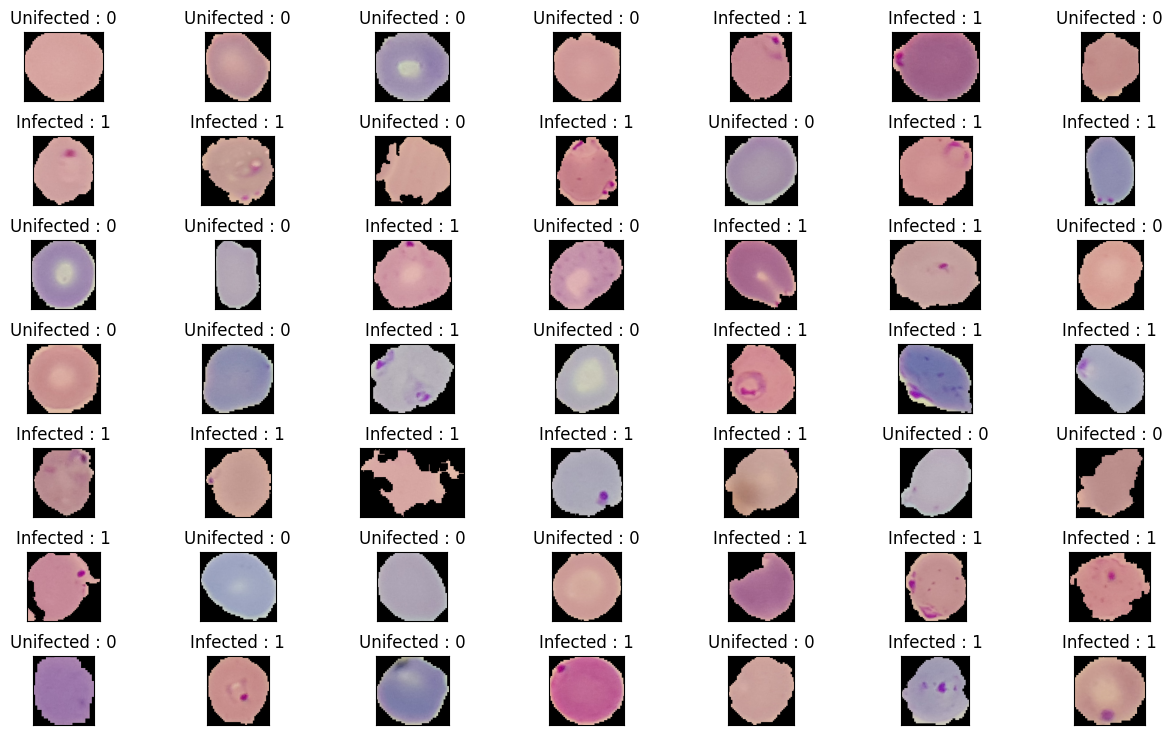

In [7]:
# Show samples of data
plt.figure(1 , figsize = (15 , 9))
n = 0 
for i in range(49):
    n += 1 
    r = np.random.randint(0 , cells_path.shape[0] , 1)
    plt.subplot(7 , 7 , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    img =cv2.imread(cells_path[r[0]])
    img = img[:, :, ::-1]
    plt.imshow(img)
    plt.title('{} : {}'.format('Infected' if labels[r[0]] == 1 else 'Unifected' ,
                               labels[r[0]]) )
    plt.xticks([]) , plt.yticks([])
    
plt.show()

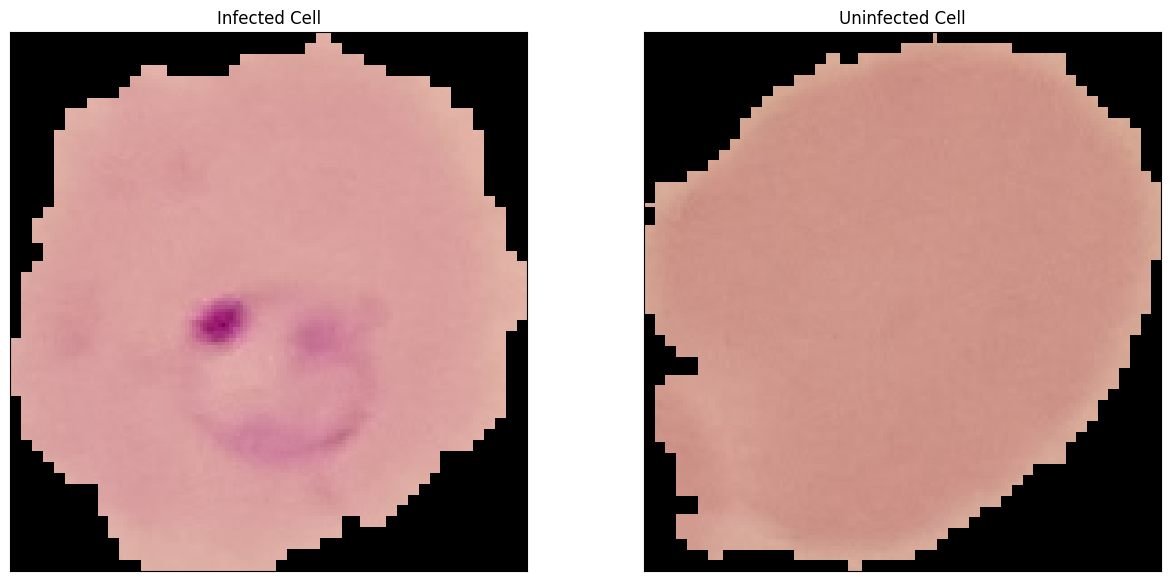

In [8]:
plt.figure(1, figsize = (15 , 7))
plt.subplot(1 , 2 , 1)
plt.imshow(cv2.imread(cells_path[0])[:, :, ::-1])
plt.title('Infected Cell')
plt.xticks([]) , plt.yticks([])

plt.subplot(1 , 2 , 2)
plt.imshow(cv2.imread(cells_path[16000])[:, :, ::-1])
plt.title('Uninfected Cell')
plt.xticks([]) , plt.yticks([])

plt.show()

In [9]:
n = np.arange(cells_path.shape[0])
np.random.seed(42)
np.random.shuffle(n)
cells = cells_path[n]
labels = labels[n]

In [10]:
np.save('shuffled_Cells' , cells)
np.save('shuffled_Labels' , labels)

In [11]:
cells = np.load('shuffled_Cells.npy')
labels = np.load('shuffled_Labels.npy')

In [12]:
# Data augmentation
initial_Augmentation = A.Compose([
    A.Resize(50, 50),
    A.SomeOf([
    A.Rotate(limit=75, p=0.5),
    A.Blur(blur_limit=5, p=0.5),
],n=1,p=1.0),
    A.Normalize(mean=(0,0,0), std=(1,1,1), max_pixel_value=255.0),
])

initial_val_test_Augmentation = A.Compose([
    A.Resize(50, 50),
    A.Normalize(mean=(0,0,0), std=(1,1,1), max_pixel_value=255.0),
])
    
improved_train_Augmentation = A.Compose([
    A.Resize(128, 128),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=180, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=15, val_shift_limit=10, p=0.3), 
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    
    A.Normalize(mean=(0,0,0), std=(1,1,1), max_pixel_value=255.0),
])

improved_val_test_Augmentation = A.Compose([
    A.Resize(128, 128),
    A.Normalize(mean=(0,0,0), std=(1,1,1), max_pixel_value=255.0),
])

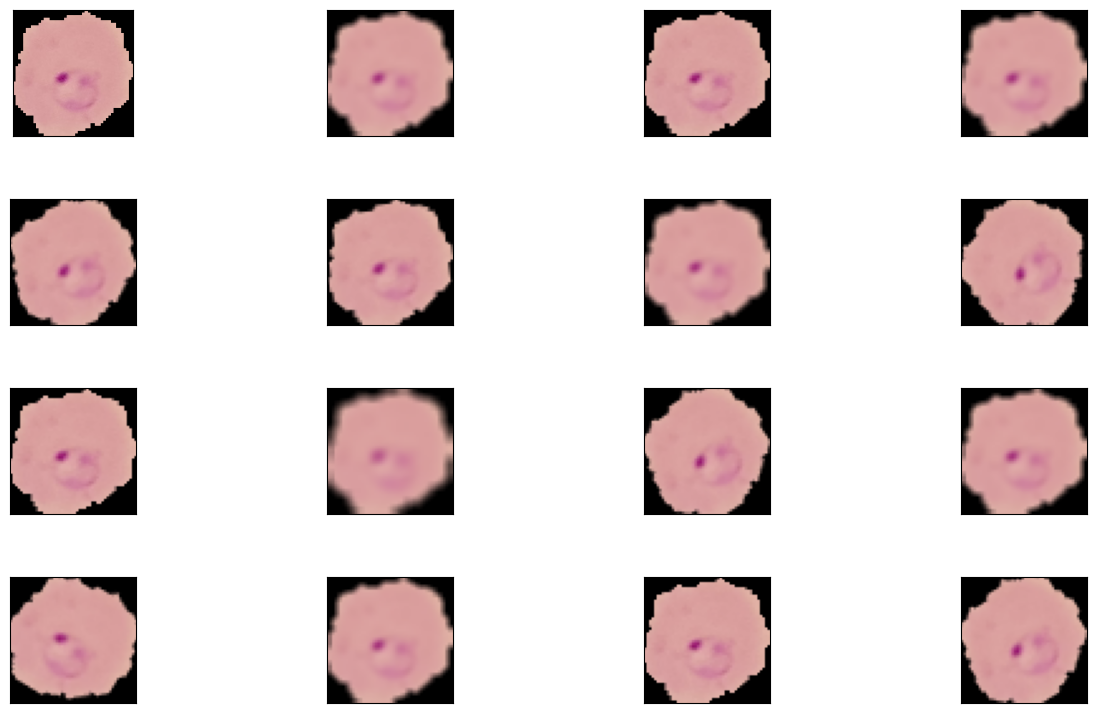

In [13]:
# Examples of variations of the image with initial augmentaion
im1 = cv2.imread(cells_path[0])[:, :, ::-1]
images_list = [im1]
im1 = np.array(im1)

for i in range(15):
    augmentation = initial_Augmentation(image=im1)
    augmented_image = augmentation['image']
    images_list.append(augmented_image)

plt.figure(1 , figsize = (15 , 9))
n = 0
for i in range(16):
    n += 1 
    plt.subplot(4 , 4 , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    plt.imshow(images_list[i])
    plt.xticks([]) , plt.yticks([])
plt.show()


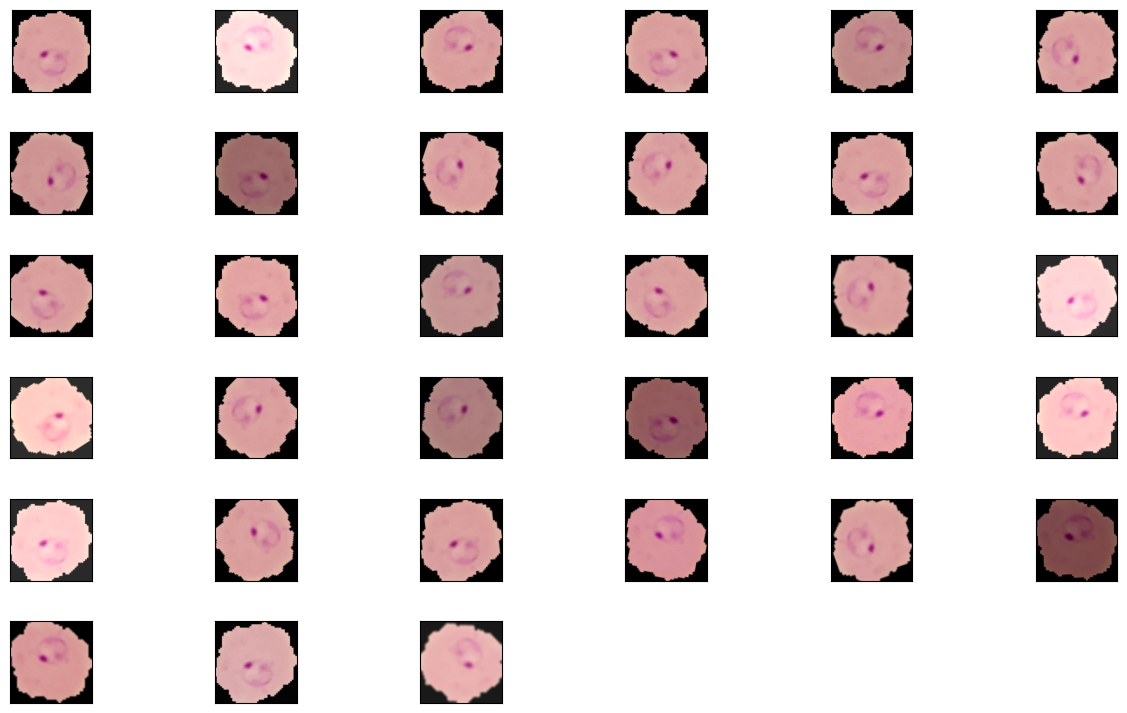

In [14]:
# Examples of variations of the image with new augmentaion
im1 = cv2.imread(cells_path[0])[:, :, ::-1]
images_list = [im1]
im1 = np.array(im1)

for i in range(32):
    augmentation = improved_train_Augmentation(image=im1)
    augmented_image = augmentation['image']
    images_list.append(augmented_image)

plt.figure(1 , figsize = (15 , 9))
n = 0
for i in range(33):
    n += 1 
    plt.subplot(6 , 6 , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    plt.imshow(images_list[i])
    plt.xticks([]) , plt.yticks([])
plt.show()

In [15]:
class DataGenerator(Sequence):
    def __init__(self, image_path, labels, batch_size=32, transform=None, shuffle=True):
        self.image_path = image_path
        self.labels = labels
        self.batch_size = batch_size
        self.transform = transform
        self.shuffle = shuffle
        self.indices = np.arange(len(self.image_path))
        self.on_epoch_end()

    def __len__(self):
        return(int(np.ceil(len(self.image_path)/self.batch_size)))
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)
    
    def __getitem__(self, index):
        index_start = index * self.batch_size
        index_end = (index + 1) * self.batch_size
        batch_indices = self.indices[index_start:index_end]

        images = []
        batch_labels = []

        for i in batch_indices:
            path = self.image_path[i]
            label = self.labels[i]

            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if self.transform:
                augmented = self.transform(image=img)
                img = augmented['image'] 
            
            images.append(img)
            batch_labels.append(label)

        return np.array(images), np.array(batch_labels)

In [16]:
from sklearn.model_selection import train_test_split

train_x , test_x , train_y , test_y = train_test_split(cells , labels , 
                                            test_size = 0.2 ,
                                            random_state = 42)

train_x , eval_x , train_y , eval_y = train_test_split(train_x , train_y , 
                                                    test_size = 0.2 , 
                                                    random_state = 42)

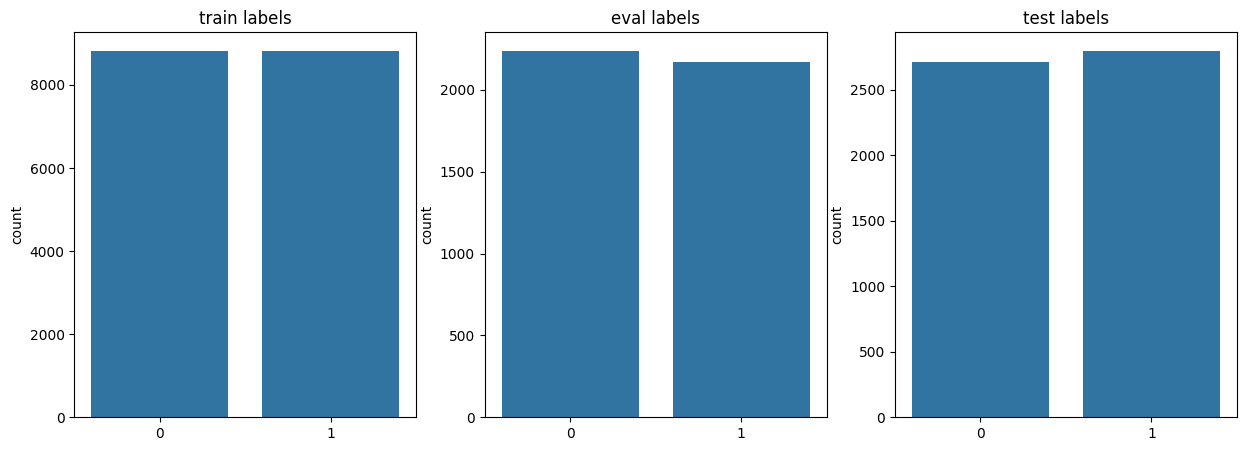

In [17]:
plt.figure(1 , figsize = (15 ,5))
n = 0 
for z , j in zip([train_y , eval_y , test_y] , ['train labels','eval labels','test labels']):
    n += 1
    plt.subplot(1 , 3  , n)
    sns.countplot(x = z )
    plt.title(j)
plt.show()

In [18]:
print('train data shape {} ,eval data shape {} , test data shape {}'.format(train_x.shape,
                                                                           eval_x.shape ,
                                                                           test_x.shape))

train data shape (17636,) ,eval data shape (4410,) , test data shape (5512,)


In [19]:
train_generator = DataGenerator(train_x, train_y, batch_size=32, transform=initial_Augmentation, shuffle=True)
val_generator = DataGenerator(eval_x, eval_y, batch_size=32, transform=initial_val_test_Augmentation, shuffle=False)
test_generator = DataGenerator(test_x, test_y, batch_size=32, transform=initial_val_test_Augmentation, shuffle=False)

In [20]:
def build_model(resize_shape=(128, 128, 3)):
    model = Sequential([
    
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=resize_shape),
        MaxPooling2D((2, 2)),
        
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation='relu'), 
        Dropout(0.5), 
        Dense(1, activation='sigmoid') 
    ])
    
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [21]:
# def build_model(resize_shape=(128, 128, 3)):
#     model = Sequential([
    
#         Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=resize_shape),
#         MaxPooling2D((2, 2)),
#         BatchNormalization(),
#         Dropout(0.3),

#         Conv2D(64, (3, 3), activation='relu', padding='same'),
#         MaxPooling2D((2, 2)),
      
#         GlobalAveragePooling2D(),
#         Dense(512, activation='relu'),
#         BatchNormalization(), 
#         Dropout(0.3), 
#         Dense(256, activation='relu'),
#         BatchNormalization(), 
#         Dense(1, activation='sigmoid'), 
#     ])
    
#     model.compile(
#         optimizer='adam', 
#         loss='binary_crossentropy',
#         metrics=['accuracy']
#     )
    
#     return model

In [23]:
model = build_model((50, 50, 3))
history = model.fit(train_generator, validation_data=val_generator, epochs=10, callbacks=[tensorboard])

Epoch 1/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 31s 54ms/step - accuracy: 0.7837 - loss: 0.4172 - val_accuracy: 0.9506 - val_loss: 0.1534
Epoch 2/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - accuracy: 0.9457 - loss: 0.1709 - val_accuracy: 0.9549 - val_loss: 0.1430
Epoch 3/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 30s 55ms/step - accuracy: 0.9507 - loss: 0.1552 - val_accuracy: 0.9558 - val_loss: 0.1296
Epoch 4/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 31s 57ms/step - accuracy: 0.9532 - loss: 0.1440 - val_accuracy: 0.9628 - val_loss: 0.1193
Epoch 5/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - accuracy: 0.9538 - loss: 0.1356 - val_accuracy: 0.9587 - val_loss: 0.1236
Epoch 6/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.9585 - loss: 0.1307 - val_accuracy: 0.9596 - val_loss: 0.1214
Epoch 7/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.9588 - loss: 0.1247 - val_accuracy: 0.9599 - val_loss: 0.1179
Epoch 8/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.9596 - loss: 0.1236 - 

In [26]:

train_generator = DataGenerator(train_x, train_y, batch_size=32, transform=improved_train_Augmentation, shuffle=True)
val_generator = DataGenerator(eval_x, eval_y, batch_size=32, transform=improved_val_test_Augmentation, shuffle=False)
test_generator = DataGenerator(test_x, test_y, batch_size=32, transform=improved_val_test_Augmentation, shuffle= False)
improved_model = build_model()
history = improved_model.fit(train_generator, validation_data=val_generator, epochs=10, callbacks=[tensorboard])

Epoch 1/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 284s 511ms/step - accuracy: 0.7395 - loss: 0.4913 - val_accuracy: 0.9385 - val_loss: 0.1773
Epoch 2/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 124s 224ms/step - accuracy: 0.9381 - loss: 0.2053 - val_accuracy: 0.9567 - val_loss: 0.1457
Epoch 3/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 124s 224ms/step - accuracy: 0.9477 - loss: 0.1752 - val_accuracy: 0.9587 - val_loss: 0.1356
Epoch 4/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 121s 218ms/step - accuracy: 0.9511 - loss: 0.1655 - val_accuracy: 0.9594 - val_loss: 0.1299
Epoch 5/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 120s 218ms/step - accuracy: 0.9514 - loss: 0.1546 - val_accuracy: 0.9594 - val_loss: 0.1253
Epoch 6/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 121s 218ms/step - accuracy: 0.9515 - loss: 0.1579 - val_accuracy: 0.9535 - val_loss: 0.1438
Epoch 7/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 120s 216ms/step - accuracy: 0.9536 - loss: 0.1498 - val_accuracy: 0.9567 - val_loss: 0.1362
Epoch 8/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 123s 223ms/step - accuracy: 0.9525 -

In [ ]:
dense_layers = [0, 1, 2]
layer_sizes = [32, 64, 128]
conv_layers = [1, 2, 3]
dense_nodes = [64, 128]
resize_shape = (128, 128, 3)
nb_of_models = len(dense_layers) * len(layer_sizes) * len(conv_layers) * len(dense_nodes)
print(f"Total number of models to test: {nb_of_models}")
for dense_layer in dense_layers:
    for conv_layer in conv_layers:
        layers_combination = list(itertools.product(layer_sizes, repeat=conv_layer))
        for conv_sizes in layers_combination:
            nodes_to_test = [0] if dense_layer == 0 else dense_nodes    
            for dense_node in nodes_to_test:
                
                K.clear_session()
                
                NAME = f"model Conv {conv_layer}-{conv_sizes}-Dense {dense_layer} ({dense_node})---{int(time.time())}"
                print(NAME)
                
                tensorboard = TensorBoard(log_dir=os.path.join("logs", NAME))

                model = Sequential()

                model.add(Input(shape=resize_shape))
                model.add(Conv2D(conv_sizes[0], (3, 3), activation='relu', padding='same', input_shape=resize_shape))
                model.add(MaxPooling2D((2, 2)))

                for l in range(conv_layer - 1):
                    model.add(Conv2D(conv_sizes[l+1], (3, 3), activation='relu', padding='same'))
                    model.add(MaxPooling2D((2, 2)))
                
                model.add(Flatten())
                
                for _ in range(dense_layer):
                    model.add(Dense(dense_node, activation='relu'))
                    model.add(Dropout(0.5))
                
                model.add(Dense(1, activation='sigmoid'))

                model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

                model.fit(train_generator, validation_data=val_generator, epochs=5, callbacks=[tensorboard])

Total number of models to test: 54
model Conv 1-(32,)-Dense 0 (0)---1772141370


c:\Users\bryan\anaconda3\envs\PROJMAST1\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 217s 391ms/step - accuracy: 0.6260 - loss: 0.7122 - val_accuracy: 0.6574 - val_loss: 0.6107
Epoch 2/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.6745 - loss: 0.6101